In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('elantra.csv')

In [2]:
df.tail(10)

,Month,Year,ElantraSales,Unemployment,Queries,CPI_energy,CPI_all
40,10,2012,14512,7.8,257,256.389,231.652
41,10,2013,14876,7.2,223,243.374,233.782
42,11,2010,8631,9.8,161,219.303,219.544
43,11,2011,12414,8.6,255,247.092,227.136
44,11,2012,15923,7.8,246,248.136,231.190
45,11,2013,16751,7.0,231,242.301,234.033
46,12,2010,13096,9.4,170,227.190,220.437
47,12,2011,13025,8.5,253,243.015,227.093
48,12,2012,19024,7.9,275,244.698,231.099
49,12,2013,21692,6.7,279,246.189,234.594


In [5]:
df = df.sort_values(by=['Year', 'Month'])
df = df.reset_index(drop=True)
df.head(10)

,Month,Year,ElantraSales,Unemployment,Queries,CPI_energy,CPI_all
0,1,2010,7690,9.7,153,213.377,217.466
1,2,2010,7966,9.8,130,209.924,217.251
2,3,2010,8225,9.9,138,209.163,217.305
3,4,2010,9657,9.9,132,209.024,217.376
4,5,2010,9781,9.6,177,206.172,217.299
5,6,2010,14245,9.4,138,204.161,217.285
6,7,2010,18215,9.5,156,206.834,217.677
7,8,2010,15181,9.5,202,208.927,218.012
8,9,2010,10062,9.5,150,209.850,218.281
9,10,2010,9497,9.5,178,216.655,219.024


<function matplotlib.pyplot.show(close=None, block=None)>

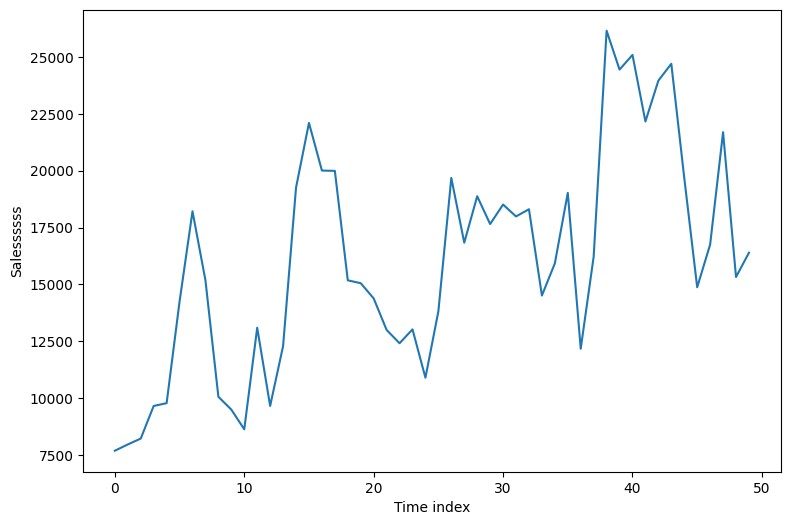

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
plt.plot(df.ElantraSales.values)
plt.xlabel('Time index')
plt.ylabel('Salessssss')
plt.show

In [8]:
numeric_feats = df.columns.drop(["ElantraSales", "Month", "Year"])
numeric_feats
#tạo một danh sách các tên cột thuộc loại dữ liệu số, lấy ra từ bảng dữ liệu df
#drop là loại bỏ ba cột cụ thể khỏi danh sách

Index(['Unemployment', 'Queries', 'CPI_energy', 'CPI_all'], dtype='str')

In [9]:
df_train = df[df.Year < 2013]
df_test = df[df.Year >= 2013]

y_train = df_train.ElantraSales.values
y_test = df_test.ElantraSales.values

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(df_train[numeric_feats])

X_train = scaler.transform(df_train[numeric_feats])
X_test = scaler.transform(df_test[numeric_feats])

In [11]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
from sklearn.metrics import mean_squared_error

def relative_error(y_true, y_pred):
    errors = np.abs(y_pred-y_true).astype(float) / y_true
    return np.mean(errors)*100

In [13]:
y_pred_test = model1.predict(X_test)
print(np.sqrt(mean_squared_error(y_test, y_pred_test)))
print('Mean relative errors ', relative_error(y_test, y_pred_test))

5017.347620904414
Mean relative errors  18.959438416755876


<function matplotlib.pyplot.show(close=None, block=None)>

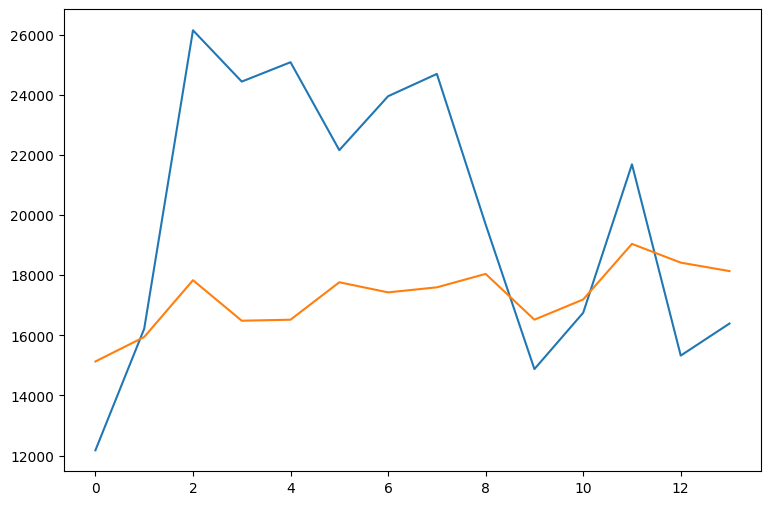

In [ ]:
plt.figure(figsize=(9,6))
plt.plot(y_test)
plt.plot(y_pred_test)
plt.show

In [15]:
month_onehot_train = pd.get_dummies(df_train.Month)
month_onehot_train.head()

,1,2,3,4,5,6,7,8,9,10,11,12
0,True,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False


In [16]:
X_train = np.hstack((X_train, month_onehot_train))
X_train[0]

array([ 1.24576653, -1.25517995, -1.21438113, -1.35903692,  1.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ])

In [17]:
X_test = np.hstack((X_test, pd.get_dummies(df_test.Month)))

In [18]:
model1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred_test = model1.predict(X_test)
print(np.sqrt(mean_squared_error(y_test, y_pred_test)))
print('Mean relative errors ', relative_error(y_test, y_pred_test))

3590.371340155823
Mean relative errors  12.78218786606422


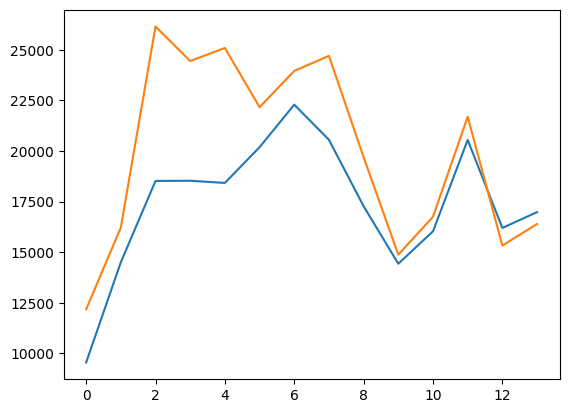

In [20]:
plt.Figure(figsize=(9,6))
plt.plot(y_pred_test)
plt.plot(y_test)
plt.show()